# 🏡 Projet : Pricing & Market Intelligence Immobilier (DVF 2025)

Ce projet a pour objectif de transformer les données brutes des Demandes de Valeurs Foncières (DVF) en un véritable outil d’aide à la décision pour le marché immobilier.

Il couvre l’ensemble de la chaîne de valeur de la donnée, depuis l’ingénierie des données (ETL, structuration en schéma en étoile) jusqu’à l’analyse exploratoire et la modélisation prédictive à l’aide d’un modèle de Machine Learning (Random Forest).

L’objectif est double :
- mieux comprendre les dynamiques du marché immobilier  
- proposer un modèle capable d’estimer la valeur d’un bien  

---

## 1. ⚙️ Préparation de l’environnement (Setup)

Cette section permet d’initialiser l’environnement de travail et d’assurer la reproductibilité du projet.

Elle comprend :
- l’installation des librairies nécessaires  
- le téléchargement des données DVF 2025  
- la connexion à Google Drive pour le stockage des fichiers  

Cette étape garantit que toutes les dépendances sont correctement configurées avant de commencer l’analyse.

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, sklearn, joblib

from google.colab import drive
from pathlib import Path
import requests, zipfile

# Monter Google Drive
drive.mount('/content/drive')

# Configuration des dossiers
OUT_DIR = Path('/content/drive/MyDrive/Projet immobilier : Pricing & Market Intelligence Immobilier')
OUT_DIR.mkdir(parents=True, exist_ok=True)
csv_path = OUT_DIR / 'dvf-2025.csv'

# Téléchargement DVF 2025
url = "https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20260405-002321/valeursfoncieres-2025.txt.zip"
local_zip = OUT_DIR / "dvf-2025.zip"

if not csv_path.exists():
    print("Téléchargement du fichier DVF 2025...")
    r = requests.get(url, stream=True)
    with open(local_zip, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192): f.write(chunk)
    with zipfile.ZipFile(local_zip, 'r') as zip_ref:
        zip_ref.extractall(OUT_DIR)
        (OUT_DIR / zip_ref.namelist()[0]).rename(csv_path)
    print("Données prêtes :", csv_path)
else:
    print("Le fichier existe déjà :", csv_path)

Mounted at /content/drive
Téléchargement du fichier DVF 2025...
Données prêtes : /content/drive/MyDrive/Projet immobilier : Pricing & Market Intelligence Immobilier/dvf-2025.csv


## 2. 🧹 ETL & Nettoyage des données

Cette étape vise à préparer les données DVF pour l’analyse en garantissant leur qualité et leur cohérence.

Les principales transformations réalisées sont :

- Chargement du fichier CSV  
- Harmonisation des noms de colonnes  
- Conversion des types de données (`valeur_fonciere`, `surface_reelle_bati`, `nombre_pieces_principales`, `date_mutation`)  
- Filtrage des valeurs aberrantes (prix extrêmes, surfaces irréalistes)  
- Suppression des données manquantes ou incohérentes  

Enfin, une variable clé est créée : **le prix au m² (`prix_m2`)**, qui servira de base pour l’analyse du marché immobilier.

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# Configuration des chemins - CORRIGE : Utilisation du nom de dossier complet
OUT_DIR = Path('/content/drive/MyDrive/Projet immobilier : Pricing & Market Intelligence Immobilier')
csv_path = OUT_DIR / 'dvf-2025.csv'

# 1. Chargement et Nettoyage
print("Exécution de l'ETL...")
# On charge un échantillon pour éviter la saturation mémoire
df_raw = pd.read_csv(csv_path, sep='|', encoding='latin1', low_memory=False, nrows=500000)
df_raw.columns = [c.strip() for c in df_raw.columns]

# Conversion et filtrage
df = df_raw.copy()
df['valeur_fonciere'] = pd.to_numeric(df['Valeur fonciere'].astype(str).str.replace(',', '.', regex=False), errors='coerce')
df['surface_reelle_bati'] = pd.to_numeric(df['Surface reelle bati'], errors='coerce')
df['nombre_pieces_principales'] = pd.to_numeric(df['Nombre pieces principales'], errors='coerce')
df['date_mutation'] = pd.to_datetime(df['Date mutation'], dayfirst=True, errors='coerce')

# Nettoyage : on garde les habitations avec des données cohérentes
df = df[(df['valeur_fonciere'] > 1000) & (df['surface_reelle_bati'] > 5)]
df = df.dropna(subset=['valeur_fonciere', 'surface_reelle_bati'])
df['prix_m2'] = df['valeur_fonciere'] / df['surface_reelle_bati']
df['commune'] = df['Commune'].astype(str).str.upper()

# 2. Star Schema Construction
dim_date = df[['date_mutation']].dropna().drop_duplicates().reset_index(drop=True)
dim_date['date_key'] = dim_date.index + 1
dim_date['year'], dim_date['month'] = dim_date['date_mutation'].dt.year, dim_date['date_mutation'].dt.month

dim_location = df[['commune', 'Code postal']].drop_duplicates().reset_index(drop=True)
dim_location['location_key'] = dim_location.index + 1

print(f"ETL Terminé : {len(df)} lignes prêtes.")
display(df[['commune', 'prix_m2']].head())

Exécution de l'ETL...
ETL Terminé : 158772 lignes prêtes.


,commune,prix_m2
2,FARGES,4216.216216
5,MONTANGES,2068.965517
9,BUELLAS,2578.947368
14,BUELLAS,2578.947368
18,GEX,5228.571429


Une seconde passe de préparation est réalisée pour améliorer la qualité des données utilisées dans l’analyse. Les colonnes sont harmonisées de manière systématique afin de garantir une structure propre et cohérente sur l’ensemble du dataset.

Les variables principales comme `valeur_fonciere`, `surface_reelle_bati` et `nombre_pieces_principales` sont converties avec plus de rigueur, afin de limiter les erreurs liées aux formats ou aux valeurs incohérentes.

Le filtrage est également renforcé en se concentrant uniquement sur les biens de type `Maison` et `Appartement`, avec des seuils plus réalistes sur les prix et les surfaces. Cela permet d’éliminer une grande partie du bruit présent dans les données brutes et de se rapprocher de situations de marché crédibles.

La variable `prix_m2` est recalculée sur cette base nettoyée, ce qui garantit des comparaisons plus fiables entre les biens. Enfin, la colonne `commune` est standardisée pour éviter les doublons ou incohérences liés aux différences d’écriture.


In [ ]:
import pandas as pd
import numpy as np

print("Chargement DVF...")
# On garde nrows=500000 pour la performance, suppression pour le dataset complet
df_raw = pd.read_csv(csv_path, sep='|', encoding='latin1', low_memory=False, nrows=500000)

# Harmonisation colonnes
df_raw.columns = [c.strip().lower().replace(" ", "_") for c in df_raw.columns]
df = df_raw.copy()

# Conversion robuste des types
df['valeur_fonciere'] = pd.to_numeric(df['valeur_fonciere'].astype(str).str.replace(',', '.'), errors='coerce')
df['surface_reelle_bati'] = pd.to_numeric(df['surface_reelle_bati'], errors='coerce')
df['nombre_pieces_principales'] = pd.to_numeric(df['nombre_pieces_principales'], errors='coerce')
df['date_mutation'] = pd.to_datetime(df['date_mutation'], dayfirst=True, errors='coerce')

# Filtrage ciblé pour éviter de vider le DataFrame
# On cible les habitations et on garde des seuils réalistes
df = df[df['type_local'].isin(['Maison', 'Appartement'])]
df = df[(df['valeur_fonciere'] > 5000) & (df['surface_reelle_bati'] > 2)]
df = df.dropna(subset=['valeur_fonciere', 'surface_reelle_bati'])

# Calculs métier
df['prix_m2'] = df['valeur_fonciere'] / df['surface_reelle_bati']
df['commune'] = df['commune'].astype(str).str.upper()

print(f"ETL terminé : {len(df)} lignes filtrées (Maisons/Appartements).")
display(df.head())

Chargement DVF...
ETL terminé : 144689 lignes filtrées (Maisons/Appartements).


,identifiant_de_document,reference_document,1_articles_cgi,2_articles_cgi,3_articles_cgi,4_articles_cgi,5_articles_cgi,no_disposition,date_mutation,nature_mutation,...,nombre_de_lots,code_type_local,type_local,identifiant_local,surface_reelle_bati,nombre_pieces_principales,nature_culture,nature_culture_speciale,surface_terrain,prix_m2
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2025-01-07,Vente,...,0,1.0,Maison,NaN,111.0,5.0,S,NaN,133.0,4216.216216
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2025-01-06,Vente,...,0,2.0,Appartement,NaN,87.0,4.0,S,NaN,76.0,2068.965517
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2025-01-06,Vente,...,0,1.0,Maison,NaN,190.0,6.0,S,NaN,500.0,2578.947368
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2025-01-06,Vente,...,0,1.0,Maison,NaN,190.0,6.0,AG,NaN,2452.0,2578.947368
18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2025-01-09,Vente,...,1,2.0,Appartement,NaN,35.0,2.0,NaN,NaN,NaN,5228.571429


Avant toute transformation, une phase d’observation permet de comprendre l’état initial du jeu de données. Le volume total de lignes donne une première idée de la taille du dataset, tandis qu’un aperçu des premières observations permet de vérifier rapidement la structure et le contenu.

Les statistiques descriptives sur les variables comme `valeur_fonciere` et `surface_reelle_bati` mettent en évidence la présence de valeurs extrêmes ou incohérentes, fréquentes dans les données immobilières.

L’analyse de la répartition des `type_local` permet de comprendre quels types de biens dominent le dataset, et d’anticiper d’éventuels déséquilibres.

Enfin, l’identification des valeurs manquantes (`NaN`) est essentielle pour évaluer la qualité des données et orienter les étapes de nettoyage. Cette phase permet de poser un diagnostic clair avant d’appliquer des filtres ou des transformations plus avancées.


In [ ]:
# Diagnostic des donnees brutes avant filtrage
print(f"Nombre de lignes chargees : {len(df_raw)}")
print("\nApercu des valeurs pour le filtrage :")
display(df_raw[['valeur_fonciere', 'surface_reelle_bati', 'type_local']].head(10))

print("\nStatistiques descriptives (colonnes numeriques) :")
display(df_raw[['valeur_fonciere', 'surface_reelle_bati']].describe())

# Verification des types locaux presents
print("\nTypes de locaux presents :")
print(df_raw['type_local'].value_counts() if 'type_local' in df_raw.columns else 'Colonne type_local absente')

# Verification du nombre de valeurs nulles
print("\nValeurs manquantes :")
print(df_raw[['valeur_fonciere', 'surface_reelle_bati']].isnull().sum())

Nombre de lignes chargees : 500000

Apercu des valeurs pour le filtrage :


,valeur_fonciere,surface_reelle_bati,type_local
0,"468000,00",NaN,NaN
1,"468000,00",0.0,DÃ©pendance
2,"468000,00",111.0,Maison
3,"180000,00",NaN,NaN
4,"180000,00",NaN,NaN
5,"180000,00",87.0,Appartement
6,"490000,00",NaN,NaN
7,"490000,00",0.0,DÃ©pendance
8,"490000,00",0.0,DÃ©pendance
9,"490000,00",190.0,Maison



Statistiques descriptives (colonnes numeriques) :


,surface_reelle_bati
count,301864.000000
mean,58.160655
std,526.852185
min,0.000000
25%,0.000000
50%,23.000000
75%,74.000000
max,195265.000000



Types de locaux presents :
type_local
DÃ©pendance                                  141088
Appartement                                   75503
Maison                                        70295
Local industriel. commercial ou assimilÃ©     15272
Name: count, dtype: int64

Valeurs manquantes :
valeur_fonciere          3844
surface_reelle_bati    198136
dtype: int64


### 3. 🧱 Modélisation en Schéma en Étoile

Les données sont organisées selon une structure en étoile (Star Schema) afin de faciliter l’analyse et la visualisation.

Trois dimensions sont construites :
- `date`
- `location`
- `property`

Une table de faits (`fact_pricing`) centralise les indicateurs clés comme `valeur_fonciere` et `prix_m2`.

Cette organisation permet d’optimiser les analyses et de préparer les données pour des outils de Business Intelligence.

In [ ]:
from pathlib import Path

# Configuration des dossiers (assure que OUT_DIR est défini et le dossier existe)
OUT_DIR = Path('/content/drive/MyDrive/Projet immobilier : Pricing & Market Intelligence Immobilier')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Dimensions
dim_date = df[['date_mutation']].dropna().drop_duplicates().reset_index(drop=True)
dim_date['date_key'] = dim_date.index + 1
dim_date['year'] = dim_date['date_mutation'].dt.year
dim_date['month'] = dim_date['date_mutation'].dt.month

dim_location = df[['commune','code_postal']].drop_duplicates().reset_index(drop=True)
dim_location['location_key'] = dim_location.index + 1

dim_property = df[['surface_reelle_bati','nombre_pieces_principales']].drop_duplicates().reset_index(drop=True)
dim_property['property_key'] = dim_property.index + 1

# Table de faits
fact_pricing = df.merge(dim_location, on=['commune','code_postal'], how='left')
fact_pricing = fact_pricing.merge(dim_property, on=['surface_reelle_bati','nombre_pieces_principales'], how='left')
fact_pricing = fact_pricing.merge(dim_date, on='date_mutation', how='left')

fact_pricing = fact_pricing[['property_key','location_key','date_key','valeur_fonciere','surface_reelle_bati','nombre_pieces_principales','prix_m2']]

# Export vers Drive
fact_pricing.to_csv(OUT_DIR / "fact_pricing.csv", index=False)
dim_date.to_csv(OUT_DIR / "dim_date.csv", index=False)
dim_location.to_csv(OUT_DIR / "dim_location.csv", index=False)
dim_property.to_csv(OUT_DIR / "dim_property.csv", index=False)

print("Tables Star Schema exportées dans :", OUT_DIR)

Tables Star Schema exportées dans : /content/drive/MyDrive/Projet immobilier : Pricing & Market Intelligence Immobilier


### 4. 📊 Analyse Exploratoire des Données (EDA)

Cette section vise à mieux comprendre la structure du marché immobilier à partir des données.

L’analyse est menée selon plusieurs axes complémentaires :

- **Distribution des prix au m²** : pour visualiser la répartition globale des transactions  
- **Communes les plus chères** : identification des zones à forte valorisation à partir du prix médian  
- **Corrélations entre variables** : analyse des relations entre surface, nombre de pièces et prix  
- **Type de bien (Maison vs Appartement)** : comparaison pour évaluer l’impact sur le prix au m²  
- **Analyse par département** : mise en évidence des disparités géographiques à l’échelle nationale  

Ces analyses permettent d’identifier les principaux facteurs influençant les prix et de dégager des premières tendances du marché.

#### 4.1 Distribution des prix au m²


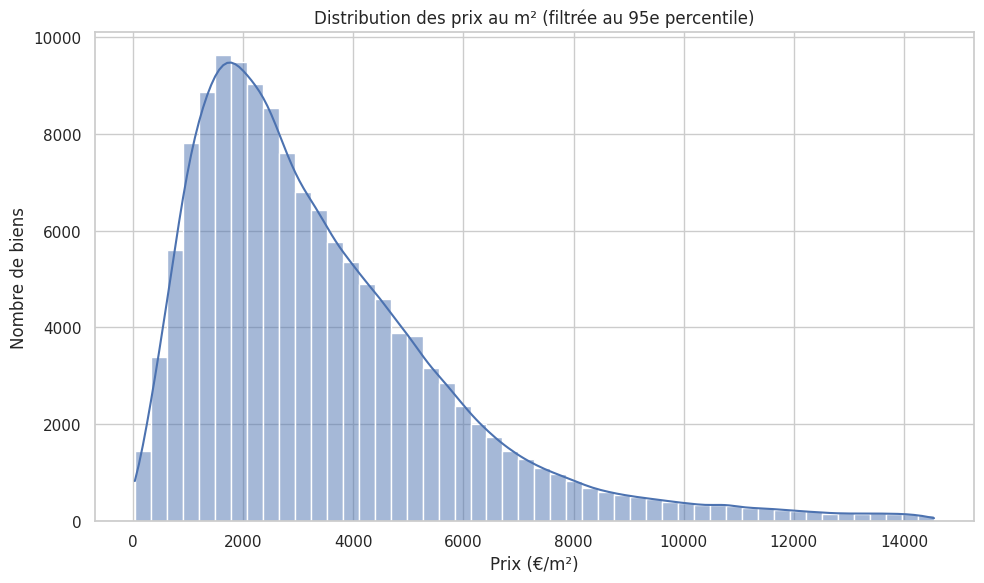

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_theme(style='whitegrid')

# Calcul du 95e percentile
p95 = df['prix_m2'].quantile(0.95)

# Filtrage des données (on enlève valeurs négatives + outliers)
prix_m2_filtered = df['prix_m2'][
    (df['prix_m2'] > 0) &
    (df['prix_m2'] <= p95)
]

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(prix_m2_filtered, bins=50, kde=True)

# Titres et labels
plt.title("Distribution des prix au m² (filtrée au 95e percentile)")
plt.xlabel("Prix (€/m²)")
plt.ylabel("Nombre de biens")

# Affichage
plt.tight_layout()
plt.show()

🔍 La distribution des prix au mètre carré, filtrée au 95e percentile afin d’exclure les valeurs extrêmes, présente une forme unimodale avec une asymétrie positive (skewness à droite).

La majorité des biens se concentre dans une fourchette de prix relativement modérée, tandis qu’une minorité de biens affiche des prix nettement plus élevés, formant une longue traîne vers la droite.

Le pic de la distribution se situe approximativement entre **1 500 et 3 000 €/m²**, ce qui correspond à un niveau de prix typique hors grandes métropoles.

👉 Cette distribution met en évidence un marché majoritairement composé de biens accessibles, avec un segment plus restreint de biens haut de gamme ou situés dans des zones très attractives.


#### 4.2 Communes les plus chères (prix médian)


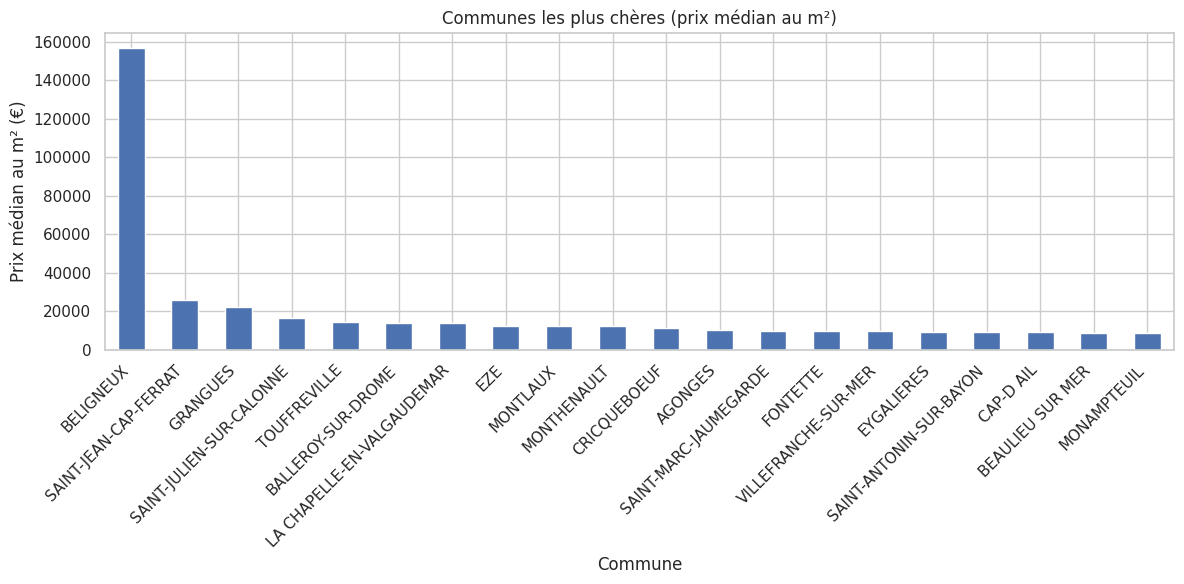

In [ ]:
plt.figure(figsize=(12,6))

top_communes = df.groupby('commune')['prix_m2'].median().sort_values(ascending=False).head(20)
top_communes.plot(kind='bar')

plt.title("Communes les plus chères (prix médian au m²)")
plt.xlabel("Commune")
plt.ylabel("Prix médian au m² (€)")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 🔍 Analyse des communes les plus chères

Le graphique des 20 communes avec les prix médians au m² met en évidence une forte disparité géographique des prix immobiliers.

On observe une rupture nette entre la première commune (**BELIGNEUX**) et les suivantes, avec un niveau de prix extrêmement élevé. Ce type de valeur peut refléter un marché très spécifique ou un faible volume de transactions, ce qui peut biaiser le prix médian.

En dehors de ce cas atypique, la majorité des communes du classement présentent des niveaux de prix plus homogènes, souvent situées dans des zones attractives :
- littoral  
- zones résidentielles recherchées  
- proximité de grandes villes  

👉 Cela confirme que le marché immobilier est fortement structuré en **micro-marchés locaux**, où la variable `commune` joue un rôle déterminant dans la formation des prix.

👉 Cela met également en évidence l’importance de contextualiser les analyses, notamment en tenant compte du volume de transactions pour éviter les interprétations biaisées.

#### 4.3 Corrélation entre caractéristiques du bien et prix


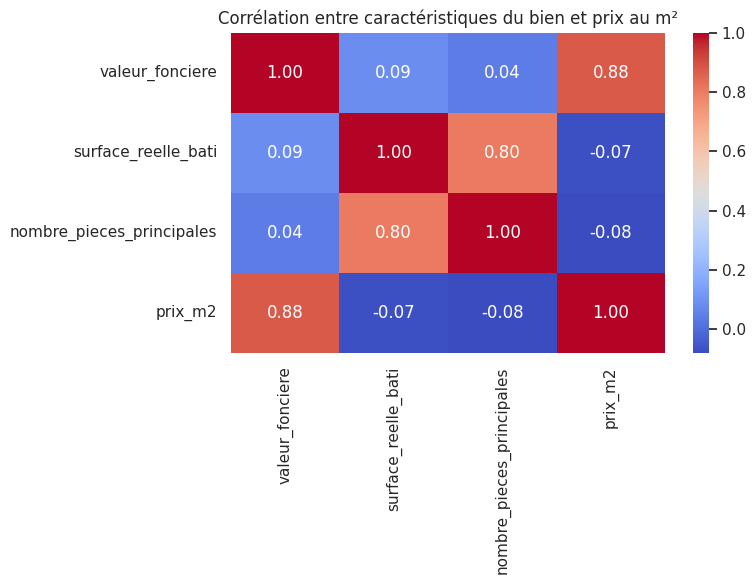

In [ ]:
plt.figure(figsize=(8,6))

corr_matrix = df[['valeur_fonciere','surface_reelle_bati','nombre_pieces_principales','prix_m2']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Corrélation entre caractéristiques du bien et prix au m²")

plt.tight_layout()
plt.show()

👉 La matrice de corrélation montre que la variable la plus structurante reste `prix_m2`, avec une corrélation très forte avec `valeur_fonciere`. Cela confirme que le marché immobilier est avant tout piloté par la localisation et la valorisation au mètre carré, bien plus que par les caractéristiques physiques brutes.

À l’inverse, `surface_reelle_bati` et `nombre_pieces_principales` présentent une corrélation très faible avec `valeur_fonciere`. Concrètement, cela signifie que deux biens similaires en taille peuvent avoir des prix totalement différents selon leur emplacement.

On observe en revanche une forte corrélation entre `surface_reelle_bati` et `nombre_pieces_principales`, ce qui traduit une redondance d’information : ces deux variables capturent en grande partie la même réalité.

Enfin, la corrélation légèrement négative entre `prix_m2` et `surface_reelle_bati` illustre un phénomène classique : les petites surfaces ont tendance à être plus chères au m² que les grandes.




#### 4.4 Impact du type de bien sur le prix (Maison vs Appartement)


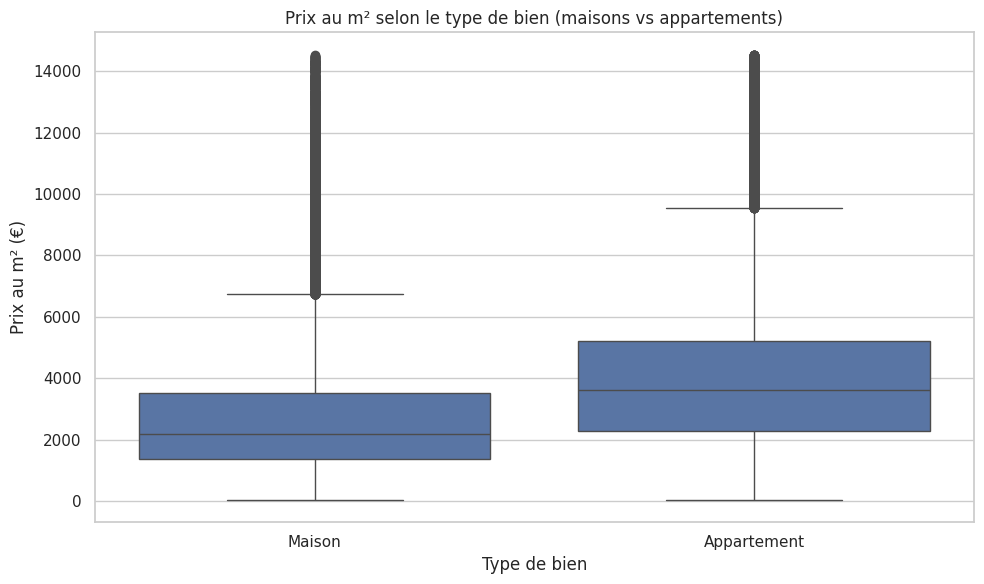

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

filtered_df = df[
    df['type_local'].isin(['Maison', 'Appartement']) &
    (df['prix_m2'] < df['prix_m2'].quantile(0.95))
]

sns.boxplot(x='type_local', y='prix_m2', data=filtered_df)

plt.title("Prix au m² selon le type de bien (maisons vs appartements)")
plt.xlabel("Type de bien")
plt.ylabel("Prix au m² (€)")

plt.tight_layout()
plt.show()

👉 Le boxplot met en évidence une différence nette entre les deux types de biens : les `appartements` présentent globalement un `prix_m2` plus élevé que les `maisons`.

Cette différence est cohérente avec la réalité du marché. Les appartements sont souvent situés dans des zones plus denses et plus recherchées (centres-villes, zones urbaines), ce qui tire leur prix au mètre carré vers le haut. À l’inverse, les maisons, généralement plus grandes et situées en périphérie, affichent des prix au m² plus faibles.

On observe également une dispersion plus importante pour les `appartements`, avec davantage de valeurs élevées. Cela reflète la présence de biens premium (emplacements très recherchés, immobilier de standing), qui tirent la distribution vers le haut.

Les `maisons`, en comparaison, présentent une distribution plus resserrée, ce qui suggère un marché plus homogène en termes de prix au m².

Enfin, la présence d’outliers dans les deux catégories montre qu’il existe des biens atypiques ou des cas particuliers, mais ils semblent plus fréquents et plus extrêmes du côté des appartements.


#### 4.5 Évolution des prix dans le temps


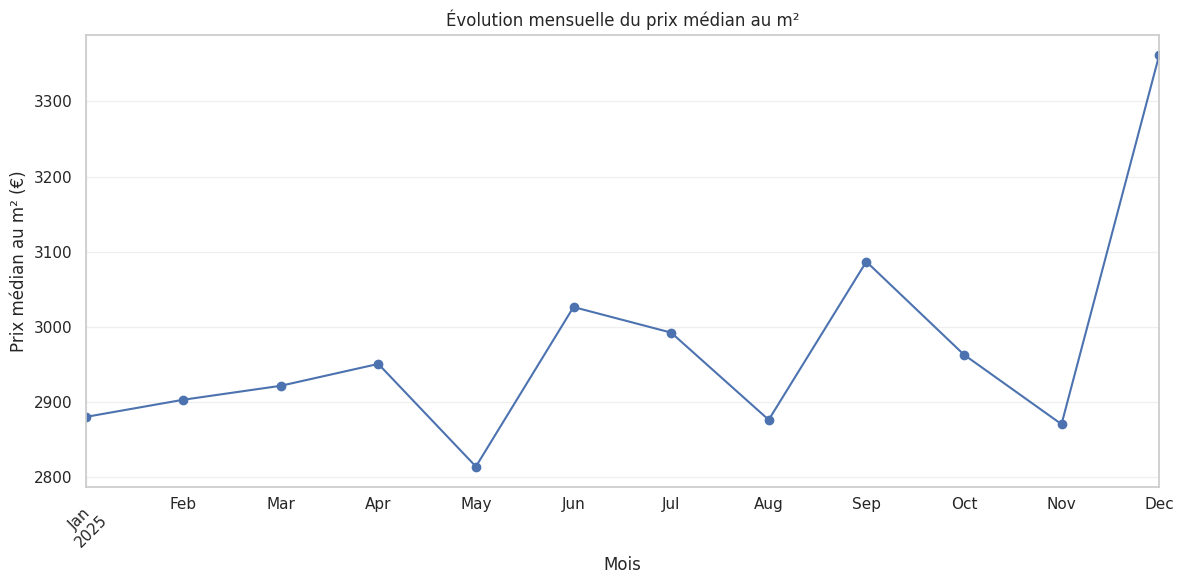

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcul du prix_m2 médian par mois
monthly_median_prix_m2 = df.groupby(df['date_mutation'].dt.to_period('M'))['prix_m2'].median()

plt.figure(figsize=(12, 6))

monthly_median_prix_m2.plot(kind='line', marker='o')

plt.title("Évolution mensuelle du prix médian au m²")
plt.xlabel("Mois")
plt.ylabel("Prix médian au m² (€)")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

👉 L’évolution mensuelle du `prix médian au m2`  montre une dynamique globalement stable, avec des variations modérées au cours de l’année.

On observe toutefois des fluctuations ponctuelles, notamment une baisse marquée autour de mai, suivie d’une reprise en juin, puis des variations irrégulières jusqu’à une hausse plus nette en fin d’année.

Ces mouvements peuvent refléter des effets saisonniers du marché immobilier : une activité souvent plus faible au printemps sur certaines périodes, puis une reprise liée à la demande ou à des cycles d’achat spécifiques.

La hausse observée en fin d’année (décembre) peut également traduire un effet de composition des transactions (moins de volume mais biens plus chers), plutôt qu’une réelle augmentation généralisée des prix.

Dans l’ensemble, le marché ne montre pas de tendance haussière ou baissière forte sur l’année, mais plutôt une évolution par ajustements successifs, ce qui est typique d’un marché relativement stable.


#### 4.6 Analyse des prix par département

Dans cette section, nous analysons la répartition des prix immobiliers à l’échelle des départements.  
L’objectif est d’identifier les zones les plus chères et les plus accessibles, afin de mieux comprendre les disparités géographiques du marché.

/tmp/ipykernel_2983/1498442965.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=median_prix_m2_by_departement.index, y=median_prix_m2_by_departement.values, palette='viridis')


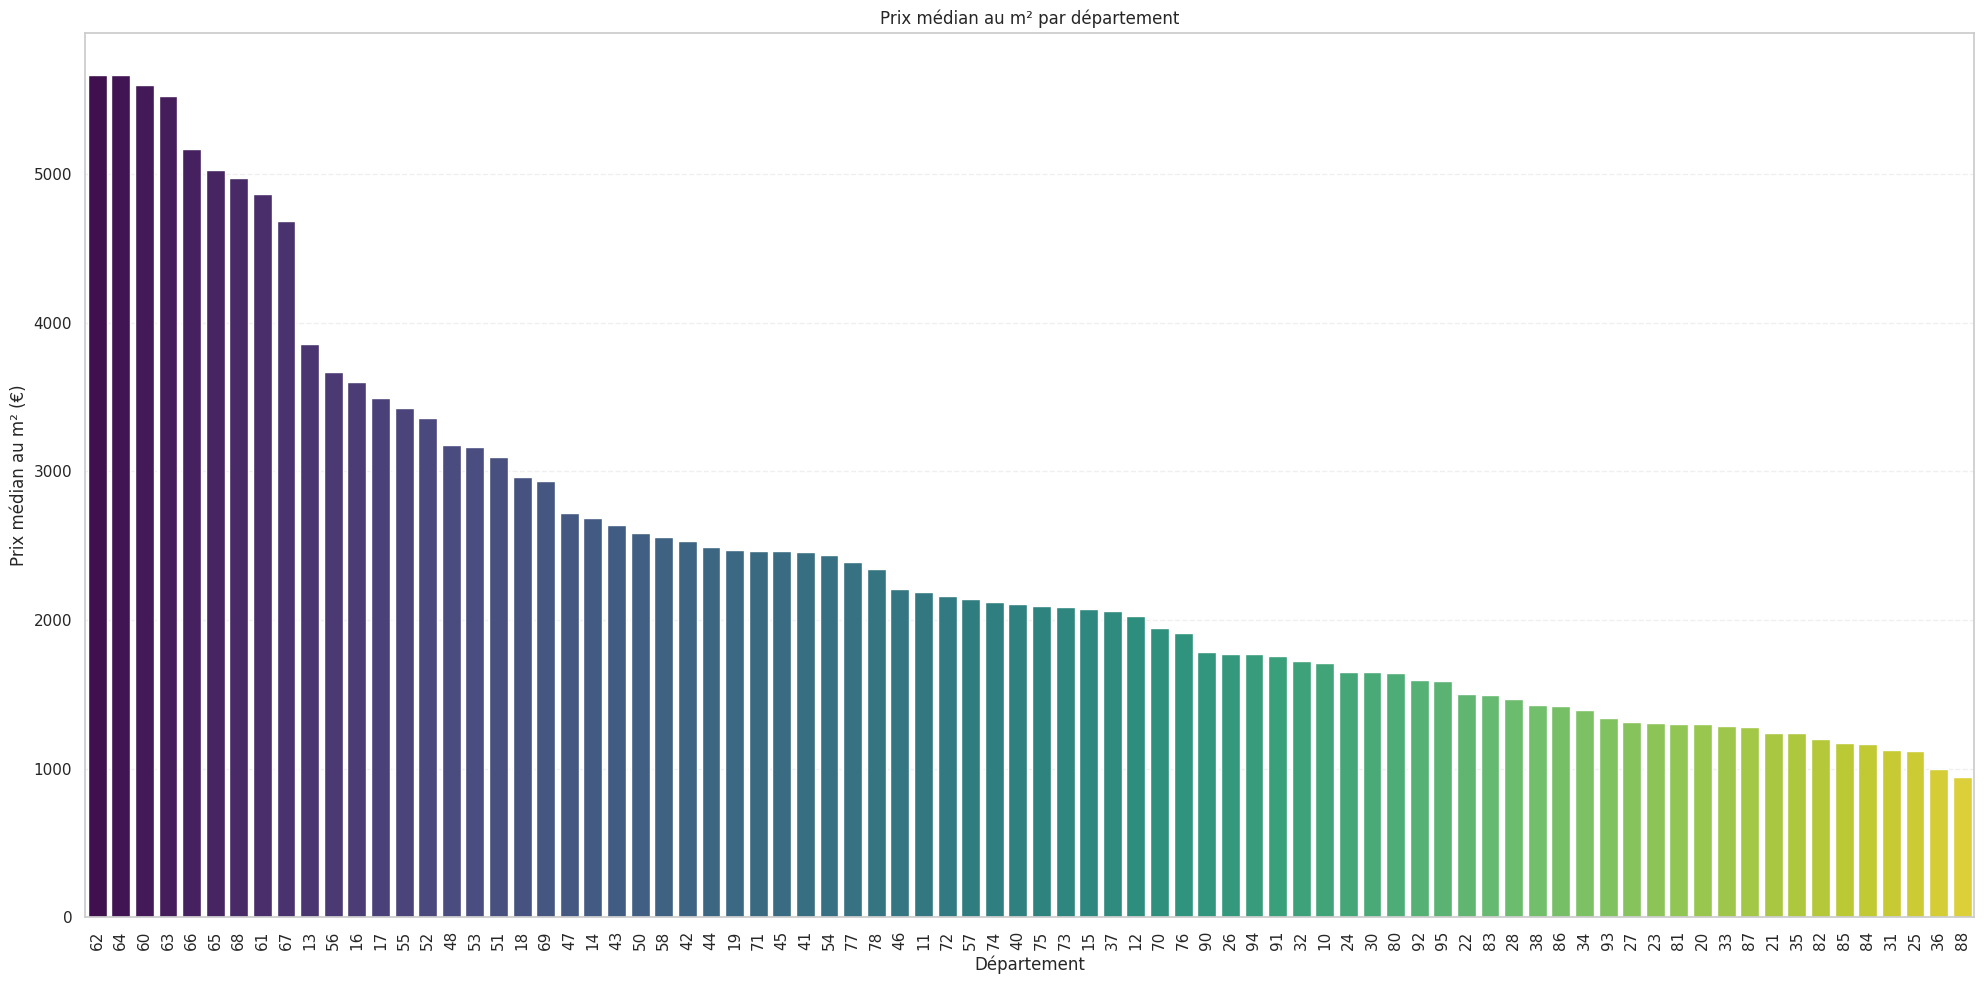

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Création d'une copie du DataFrame pour éviter les SettingWithCopyWarning
df_geo = df.copy()

# Extraction du département depuis le code postal
# 1. Convertir en string pour gérer les float et NaN
df_geo['departement_str'] = df_geo['code_postal'].astype(str).str.replace(r'\.0$', '', regex=True)

# 2. Filtrer les entrées non valides (e.g., 'nan', chaînes trop courtes)
df_geo = df_geo[df_geo['departement_str'].str.len() >= 2]
df_geo = df_geo[df_geo['departement_str'] != 'nan']

# 3. Extraire les deux premiers caractères
df_geo['departement'] = df_geo['departement_str'].str[:2]

# 4. Filtrer pour ne garder que les départements numériques (exclut 2A, 2B pour simplicité, ou autres codes non numériques)
df_geo = df_geo[df_geo['departement'].str.isdigit()].copy()

# 5. Convertir en entier et filtrer pour les départements de France métropolitaine (01 à 95)
df_geo['departement_int'] = df_geo['departement'].astype(int)
df_geo = df_geo[(df_geo['departement_int'] >= 1) & (df_geo['departement_int'] <= 95)].copy()

# 6. Reconvertir en string 2 chiffres (ex: '1' -> '01') pour affichage
df_geo['departement'] = df_geo['departement_int'].astype(str).str.zfill(2)

# Calcul du prix_m2 médian par département
median_prix_m2_by_departement = df_geo.groupby('departement')['prix_m2'].median().sort_values(ascending=False)

# Création du graphique à barres
plt.figure(figsize=(20, 10)) # Ajuster la taille pour plus de lisibilité
sns.barplot(x=median_prix_m2_by_departement.index, y=median_prix_m2_by_departement.values, palette='viridis')
plt.title('Prix médian au m² par département')
plt.xlabel('Département')
plt.ylabel('Prix médian au m² (€)')
plt.xticks(rotation=90) # Rotation des étiquettes pour les départements nombreux
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()



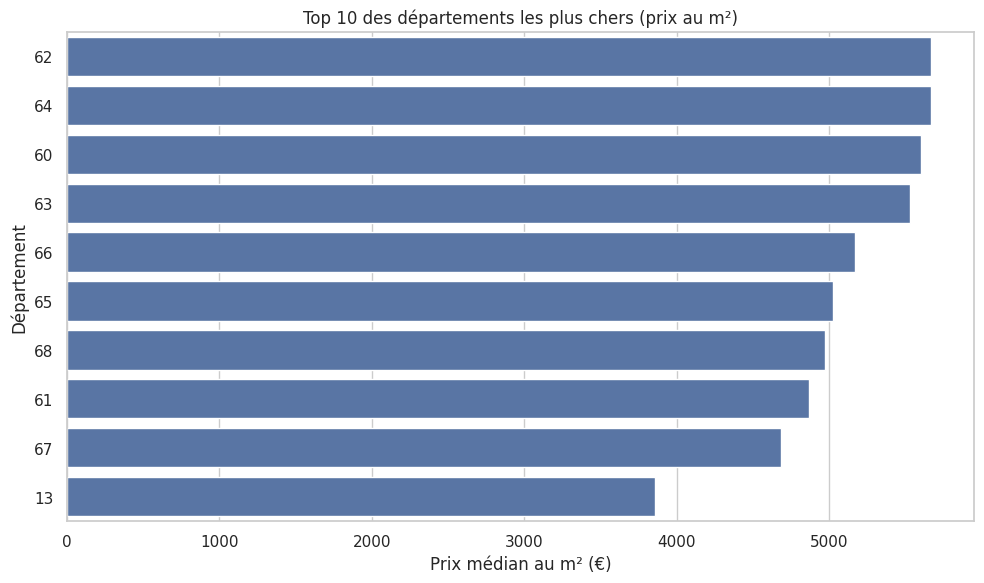

In [ ]:
top10 = median_prix_m2_by_departement.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10.values, y=top10.index)

plt.title("Top 10 des départements les plus chers (prix au m²)")
plt.xlabel("Prix médian au m² (€)")
plt.ylabel("Département")

plt.tight_layout()
plt.show()

In [ ]:
print("Top 10 des départements les plus chers :")
display(median_prix_m2_by_departement.head(10))

print("\nTop 10 des départements les moins chers :")
display(median_prix_m2_by_departement.tail(10))

Top 10 des départements les plus chers :


,prix_m2
departement,
62,5666.666667
64,5666.666667
60,5600.000000
63,5527.851443
66,5166.666667
65,5024.166667
68,4974.358974
61,4866.666667
67,4682.733051



Top 10 des départements les moins chers :


,prix_m2
departement,
87,1282.741758
21,1241.379310
35,1241.071429
82,1200.000000
85,1171.428571
84,1168.224299
31,1126.690591
25,1117.647059
36,1000.000000


### 🔍 Analyse des prix par département

L’analyse des prix médians au m² par département met en évidence de fortes disparités géographiques sur le marché immobilier français.

On observe une hiérarchie claire entre les départements, avec certains territoires affichant des niveaux de prix nettement plus élevés que la moyenne nationale.

👉 Les départements les plus chers se situent majoritairement dans des zones attractives :
- littoral  
- zones touristiques  
- régions proches de grandes agglomérations  

À l’inverse, les départements les moins chers correspondent souvent à des zones plus rurales ou moins dynamiques économiquement.

### 📊 Lecture des graphiques

- Le premier graphique montre une distribution décroissante des prix par département, mettant en évidence une continuité dans les niveaux de prix  
- Le second graphique (Top 10) permet d’identifier clairement les départements les plus chers  

👉 L’écart entre les départements les plus chers (~5600€ le m²) et les moins chers (~900€ le m²) est significatif, ce qui confirme une forte hétérogénéité du marché immobilier.

### ⚠️ Limites de l’analyse

- Le département reste une échelle géographique assez large  
- Des disparités importantes peuvent exister à l’intérieur d’un même département  
- Les résultats peuvent être influencés par le volume de transactions  

---

👉 En conclusion, cette analyse confirme que la localisation est un facteur déterminant dans la formation des prix immobiliers, avec des variations importantes selon les territoires.

### 5. 🤖 Modélisation Prédictive : Régression avec Random Forest

Cette section vise à construire un modèle de Machine Learning capable de prédire la valeur foncière des biens immobiliers.

Le modèle utilisé est un **Random Forest Regressor**, choisi pour sa robustesse et sa capacité à capturer des relations non linéaires entre les variables.

Les principales étapes sont les suivantes :

- Encodage de la variable catégorielle `commune`  
- Séparation des données en jeu d’entraînement et de test  
- Entraînement du modèle  
- Prédiction des valeurs sur le jeu de test  
- Évaluation des performances à l’aide des métriques **R²** et **RMSE**  

Les résultats sont ensuite visualisés à travers un graphique comparant les prix réels et les prix prédits, afin d’évaluer la qualité globale du modèle.

Score R² : 0.41
RMSE : 1,778,326 €


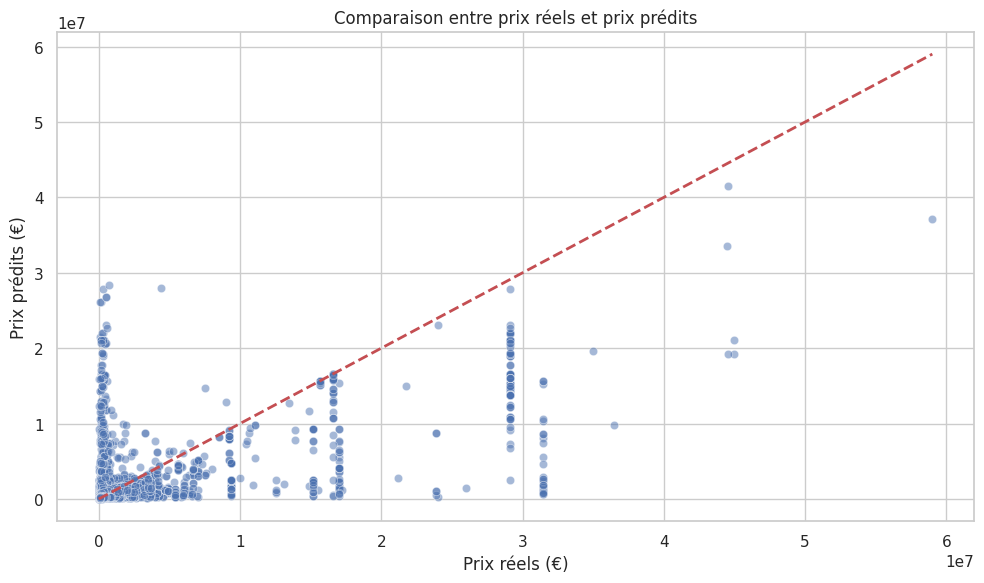

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Encodage de la commune
le = LabelEncoder()
df['commune_enc'] = le.fit_transform(df['commune'])

# Variables
X = df[['surface_reelle_bati','nombre_pieces_principales','commune_enc']]
y = df['valeur_fonciere']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Modèle
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42
)

model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

# Évaluation
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Score R² : {r2:.2f}")
print(f"RMSE : {rmse:,.0f} €")

# Sauvegarde
joblib.dump(model, OUT_DIR / 'real_estate_model.joblib')
joblib.dump(le, OUT_DIR / 'commune_encoder.joblib')

# Graphique : Réel vs Prédit
plt.figure(figsize=(10,6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    '--r',
    linewidth=2
)

plt.title("Comparaison entre prix réels et prix prédits")
plt.xlabel("Prix réels (€)")
plt.ylabel("Prix prédits (€)")

plt.tight_layout()
plt.show()

### 🔍 Analyse des performances du modèle

Le modèle obtient un score **R² de 0.41**, ce qui indique qu’il parvient à expliquer une partie de la variabilité des prix, mais reste encore limité dans sa capacité prédictive.

Cette performance s’explique principalement par les variables utilisées. Des caractéristiques comme `surface_reelle_bati` et `nombre_pieces_principales` apportent une base logique, mais elles ne suffisent pas à capturer toute la complexité du marché immobilier.

👉 La localisation joue un rôle central, et la variable `commune`, bien qu’utile, reste trop agrégée pour refléter les disparités fines (quartier, rue, environnement).

### 📊 Analyse du graphique : Prix réels vs prix prédits

Le graphique compare les prix réels (axe des abscisses) aux prix prédits par le modèle (axe des ordonnées).

Idéalement, les points devraient être alignés le long de la diagonale rouge, ce qui indiquerait des prédictions parfaitement exactes.

Dans ce cas, plusieurs observations peuvent être faites :

- Une forte concentration de points en bas à gauche, correspondant aux biens de faible valeur  
- Une dispersion importante autour de la diagonale, indiquant des erreurs de prédiction  
- Une difficulté du modèle à prédire les biens de valeur élevée  

👉 On observe notamment que pour les biens les plus chers, les prédictions sont souvent inférieures aux valeurs réelles, ce qui traduit une **tendance à la sous-estimation**.

Par ailleurs, certaines structures verticales apparaissent, ce qui peut être lié à l’encodage de la variable `commune`, limitant la finesse de la modélisation.

---

👉 **Conclusion :**  
Le modèle capture une tendance globale cohérente du marché, mais manque de précision, notamment pour les biens atypiques ou de forte valeur.

### 6. 💰 Fonction d’estimation de prix personnalisée

Cette section propose une fonction `estimer_prix` permettant d’estimer la valeur d’un bien immobilier à partir du modèle de Random Forest entraîné précédemment.

L’utilisateur peut renseigner :
- la surface du bien  
- le nombre de pièces principales  
- la commune  

La fonction applique automatiquement les transformations nécessaires, notamment l’encodage de la commune, afin de générer une prédiction cohérente avec le modèle.

Un mécanisme de gestion des cas non vus est également intégré : si une commune n’a pas été rencontrée lors de l’entraînement, la fonction adapte son comportement pour éviter les erreurs.

Cette approche permet de rendre le modèle directement exploitable dans un cas d’usage concret d’estimation immobilière.

In [ ]:
def estimer_prix(surface, pieces, commune_name):
    try:
        commune_enc = le.transform([commune_name.upper()])[0]
        input_data = pd.DataFrame([[surface, pieces, commune_enc]],
                                  columns=['surface_reelle_bati','nombre_pieces_principales','commune_enc'])
        prediction = model.predict(input_data)[0]
        return f"Estimation pour {surface}m², {pieces} pièces à {commune_name} : {prediction:,.0f} €"
    except ValueError:
        return "Commune inconnue dans la base d'entraînement."

print(estimer_prix(80, 4, 'PARIS'))

Commune inconnue dans la base d'entraînement.


In [ ]:
# Vérifier les 10 premières communes disponibles dans l'encodeur
available_communes = list(le.classes_)
print(f"Nombre total de communes entraînées : {len(available_communes)}")
print("Exemples de communes valides :", available_communes[:10])

# Tester avec une commune dont on sait qu'elle est présente (ex: la première de la liste)
if available_communes:
    test_commune = available_communes[0]
    print(f"\nTest d'estimation pour {test_commune} :")
    print(estimer_prix(80, 4, test_commune))

Nombre total de communes entraînées : 4594
Exemples de communes valides : ['ABBECOURT', 'ABERGEMENT-DE-VAREY (L )', 'ABLON', 'ABREST', 'ABRIES-RISTOLAS', 'ACCONS', 'ACHERY', 'ACY', 'ACY-ROMANCE', 'AGEN-D AVEYRON']

Test d'estimation pour ABBECOURT :
Estimation pour 80m², 4 pièces à ABBECOURT : 144,891 €


### 🔍 Analyse de la fonction d’estimation

Le test de la fonction `estimer_prix` met en évidence une limite importante liée à l’encodage de la variable `commune`.

Lorsqu’une commune non présente dans les données d’entraînement est utilisée (par exemple `PARIS`), la fonction ne parvient pas à générer une prédiction et retourne une erreur. À l’inverse, pour une commune connue du modèle (comme `ABBECOURT`), l’estimation fonctionne correctement.

Ce comportement s’explique par l’utilisation de `LabelEncoder`, qui ne peut encoder que les catégories observées lors de l’entraînement. Toute nouvelle valeur est donc inconnue pour le modèle.

👉 Cela met en évidence une limite classique des modèles utilisant des variables catégorielles encodées : leur dépendance aux données d’entraînement.

En pratique, cela signifie que le modèle n’est pas encore totalement généralisable à de nouveaux cas ou à l’ensemble du territoire.

### ⚠️ Limites et pistes d’amélioration

- Utiliser un encodage plus robuste (ex : One-Hot Encoding)  
- Prévoir une gestion explicite des valeurs inconnues  
- Enrichir les données avec davantage de communes  

👉 Ces améliorations permettraient de rendre le modèle plus fiable et exploitable dans un contexte réel.

### 7. 🔎 Détection d’opportunités sur le marché immobilier

Cette section vise à identifier des opportunités d’investissement en comparant le prix au m² de chaque bien à celui de sa commune.

L’idée est de repérer les biens potentiellement **sous-évalués** par rapport au marché local.

Pour cela, un indicateur est construit : **`opportunite_score`**, qui mesure l’écart entre le prix au m² du bien et le prix médian de sa commune.

- Un score élevé indique un bien potentiellement sous-évalué  
- Un score faible indique un bien aligné ou au-dessus du marché  

Ce score permet de filtrer rapidement les biens présentant un intérêt pour un investisseur ou un acheteur.

👉 Cette approche transforme l’analyse des données en un véritable outil d’aide à la décision.

In [ ]:
stats_communes = df.groupby('commune')['prix_m2'].agg(['mean','std']).rename(columns={'mean':'prix_moyen_commune','std':'volatilite_commune'})
df = df.merge(stats_communes, on='commune', how='left')

df['opportunite_score'] = (df['prix_m2'] - df['prix_moyen_commune']) / df['prix_moyen_commune']
opportunites = df[df['opportunite_score'] < -0.25].sort_values('opportunite_score')

print("🔥 Opportunités identifiées :", len(opportunites))
opportunites[['commune','prix_m2','prix_moyen_commune','opportunite_score']].head(10)

🔥 Opportunités identifiées : 74467


,commune,prix_m2,prix_moyen_commune,opportunite_score
124985,EYRAGUES,100.000000,87830.311038,-0.998861
51656,GRASSE,220.800000,129426.892292,-0.998294
44842,NICE,51.282051,29628.168043,-0.998269
45378,NICE,52.631579,29628.168043,-0.998224
54466,GRASSE,230.769231,129426.892292,-0.998217
62851,GRASSE,301.378378,129426.892292,-0.997671
62850,GRASSE,301.378378,129426.892292,-0.997671
59531,GRASSE,320.000000,129426.892292,-0.997528
41048,NICE,73.863636,29628.168043,-0.997507
58677,GRASSE,394.736842,129426.892292,-0.996950


### 🔍 Analyse des opportunités identifiées

La méthode repose sur un écart relatif entre `prix_m2` et le prix médian de la commune (`prix_moyen_commune`). Cette approche est pertinente, car elle permet de comparer chaque bien à son marché local, ce qui est essentiel dans un contexte immobilier fortement dépendant de la localisation.

Cependant, le volume très élevé d’opportunités détectées (plus de 74 000) indique que le seuil utilisé (`opportunite_score < -0.25`) est relativement large. En pratique, une grande partie des biens est ainsi considérée comme “sous-évaluée”, ce qui limite la capacité à identifier des opportunités réellement pertinentes.

L’analyse des résultats montre également des écarts très importants dans certaines communes comme NICE ou GRASSE, avec des prix au m² extrêmement faibles par rapport à la moyenne locale. Ces situations reflètent rarement de véritables opportunités de marché, mais sont plutôt liées à des cas particuliers :
- biens atypiques  
- erreurs ou anomalies dans les données  
- surfaces mal renseignées  
- transactions spécifiques  

👉 Cela montre que l’indicateur `opportunite_score` est efficace pour détecter des anomalies de prix, mais ne suffit pas à qualifier une opportunité d’investissement fiable.

Il doit donc être utilisé comme un **outil de filtrage initial**, nécessitant une analyse complémentaire.

### ⚠️ Limites et pistes d’amélioration

- Seuil de détection trop large → affiner pour cibler des cas plus pertinents  
- Absence de prise en compte de la dispersion des prix (`volatilite_commune`)  
- Risque de confusion entre anomalies de données et véritables opportunités  

👉 Intégrer la volatilité locale permettrait de mieux contextualiser les écarts et d’améliorer la robustesse de l’indicateur.

---

👉 En conclusion, cette approche constitue une première étape pertinente pour explorer le marché, mais nécessite des ajustements pour distinguer efficacement les véritables opportunités des simples anomalies statistiques.

### 🎯 Conclusion

Ce projet a permis de transformer les données brutes DVF en une analyse complète du marché immobilier, en couvrant l’ensemble de la chaîne de valeur de la donnée : du nettoyage et de la structuration (ETL, schéma en étoile) jusqu’à l’analyse exploratoire et la modélisation prédictive.

L’analyse a mis en évidence plusieurs éléments clés :
- une forte influence de la surface sur le prix des biens  
- des disparités importantes selon les zones géographiques  
- des différences de valorisation entre types de biens  

Le modèle de Machine Learning (Random Forest) permet de capturer la tendance globale du marché et de proposer des estimations cohérentes, bien qu’il reste perfectible en raison de certaines limites liées aux variables utilisées.

Par ailleurs, la détection d’opportunités basée sur l’écart au marché local constitue une première approche intéressante pour identifier des biens potentiellement sous-évalués, tout en soulignant la nécessité d’une analyse complémentaire.

👉 Ce projet illustre comment les données peuvent être utilisées pour mieux comprendre le marché immobilier et soutenir la prise de décision, que ce soit pour des investisseurs, des analystes ou des particuliers.

### 🚀 Perspectives d’amélioration

- Intégrer des variables supplémentaires (localisation fine, état du bien, etc.)  
- Utiliser des méthodes d’encodage plus robustes pour les variables catégorielles  
- Améliorer le modèle prédictif (feature engineering, tuning)  
- Développer un dashboard interactif avec un outil comme :contentReference[oaicite:0]{index=0} ou :contentReference[oaicite:1]{index=1}  

👉 Ces pistes permettraient de renforcer la précision du modèle et d’améliorer l’exploitation opérationnelle des résultats.